# 01 — Data Preprocessing

**Pipeline stage:** `Raw Sensor Data -> Health Indicator`

This notebook builds the AeroRUL feature-engineering pipeline from scratch, one step at a
time, on the NASA CMAPSS turbofan degradation dataset. By the end we'll have gone from raw
whitespace-separated sensor logs to a fully engineered, model-ready feature matrix — and
seen *why* each step is necessary, not just that it runs.

**Dataset:** 4 subsets (FD001-FD004) of simulated turbofan engine runs. Each row is one
engine-cycle: 3 operational settings + 21 sensor channels. Training engines run to failure;
test engines are truncated before failure with a known true Remaining Useful Life (RUL).

**Steps covered:**
1. Load raw data and understand the schema
2. Label RUL with the piecewise-linear degradation model (train) and the censored/truncated
   case (test)
3. Cluster operating conditions and normalize sensors within each one
4. Smooth sensor noise with rolling-window statistics
5. Derive a single-number Health Indicator
6. Assemble everything into the final feature matrix and cache it to disk


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from aerorul.data.loader import load_subset
from aerorul.data.schema import SENSOR_DESCRIPTIONS, SUBSET_INFO
from aerorul.features.engineering import (
    add_rul_test,
    add_rul_train,
    add_rolling_features,
    assign_operating_condition,
    compute_health_indicator,
    normalize_by_condition,
    select_feature_columns,
)
from aerorul.features.pipeline import build_training_data

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
pd.set_option("display.max_columns", 30)


## 1. Load raw data

We'll use **FD001** (single operating condition, single fault mode — the simplest subset)
as the running example for most of this notebook, then switch to **FD002** (six operating
conditions) specifically to demonstrate condition-aware normalization, since that's the step
FD001 doesn't exercise.


In [2]:
fd001 = load_subset("FD001")

print("train:", fd001.train.shape)
print("test: ", fd001.test.shape)
print("rul_truth (one value per test engine):", fd001.rul_truth.shape)
fd001.train.head()


train: (20631, 26)
test:  (13096, 26)
rul_truth (one value per test engine): (100,)


,unit_number,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,s_6,s_7,s_8,s_9,s_10,s_11,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


Every subset advertises its scale and difficulty up front: how many engines, how many
operating conditions, how many distinct fault modes.


In [3]:
pd.DataFrame(SUBSET_INFO).T


,conditions,fault_modes,train_units,test_units
FD001,1,1,100,100
FD002,6,1,260,259
FD003,1,2,100,100
FD004,6,2,248,249


### Sensor schema

21 sensor channels, each measuring a different physical quantity in the engine (temperatures,
pressures, rotational speeds, flows). A handful of these turn out to be exactly what a
prognostics model should key off of — for instance, sensors reading temperature at the LPT
outlet (`s_4`) and HPC outlet (`s_3`) are classic degradation indicators in turbofan
literature, since compressor and turbine wear directly show up as efficiency loss there.


In [4]:
sensor_table = pd.DataFrame(SENSOR_DESCRIPTIONS, index=["description", "units"]).T
sensor_table.index.name = "sensor"
sensor_table


,description,units
sensor,,
s_1,Total temperature at fan inlet,degR
s_2,Total temperature at LPC outlet,degR
s_3,Total temperature at HPC outlet,degR
s_4,Total temperature at LPT outlet,degR
s_5,Pressure at fan inlet,psia
s_6,Total pressure in bypass-duct,psia
s_7,Total pressure at HPC outlet,psia
s_8,Physical fan speed,rpm
s_9,Physical core speed,rpm


## 2. RUL labeling

The raw data has no target column — just `time_cycles`. For a **training** engine (which
runs all the way to failure), Remaining Useful Life at any cycle is simply
`(last cycle observed) - (current cycle)`. But an engine barely shows wear in its first 100
cycles — asking a regressor to distinguish "300 cycles left" from "280 cycles left" from
noisy sensor readings alone is a target the data has no signal for, and training on it just
adds noise to the loss. The standard fix (used across the CMAPSS literature) is a
**piecewise-linear degradation model**: cap RUL at some ceiling (125 cycles is the common
choice, used here) so the model spends its capacity learning the part of the curve that
actually has signal — the descent toward failure.


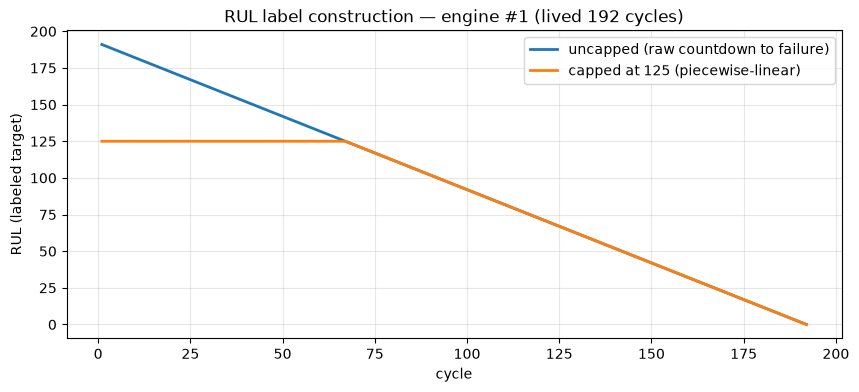

In [5]:
example = fd001.train[fd001.train.unit_number == 1]

uncapped = add_rul_train(example, rul_cap=None)
capped = add_rul_train(example, rul_cap=125)

fig, ax = plt.subplots()
ax.plot(uncapped.time_cycles, uncapped.RUL, label="uncapped (raw countdown to failure)", lw=2)
ax.plot(capped.time_cycles, capped.RUL, label="capped at 125 (piecewise-linear)", lw=2)
ax.set_xlabel("cycle")
ax.set_ylabel("RUL (labeled target)")
ax.set_title(f"RUL label construction — engine #1 (lived {example.time_cycles.max()} cycles)")
ax.legend()
plt.show()


### The test set is a *censoring* problem, not a labeling problem

Test engines are deliberately truncated before failure — that's the whole point of the
benchmark: predict how much life is left in an engine we haven't seen fail yet. NASA
supplies the true answer separately, in `RUL_*.txt`, as the number of cycles remaining **at
the last observed cycle**. Every earlier cycle's RUL is that same value plus however many
cycles remain until the truncation point.


In [6]:
test_example = fd001.test[fd001.test.unit_number == 1]
true_rul_at_truncation = fd001.rul_truth.loc[1]
labeled_test = add_rul_test(test_example, fd001.rul_truth, rul_cap=None)

print(f"Engine #1 test trajectory: observed for {len(test_example)} cycles, "
      f"then truncated with {true_rul_at_truncation} cycles still remaining (unobserved).")
labeled_test[["time_cycles", "RUL"]].tail()


Engine #1 test trajectory: observed for 31 cycles, then truncated with 112 cycles still remaining (unobserved).


,time_cycles,RUL
26,27,116
27,28,115
28,29,114
29,30,113
30,31,112


## 3. Operating-condition clustering + per-condition normalization

FD001 runs at a single operating condition, so a sensor's *absolute* value is already
comparable across an engine's whole life. FD002 runs at **six**, and the same sensor can
read completely differently depending on which regime the engine happens to be in at that
moment — that's a confound, not degradation. NASA doesn't give us clean condition labels
(the three operational settings have simulation noise), so we recover the regimes with
KMeans, then z-score each sensor *within its condition* using statistics fit on the training
set.


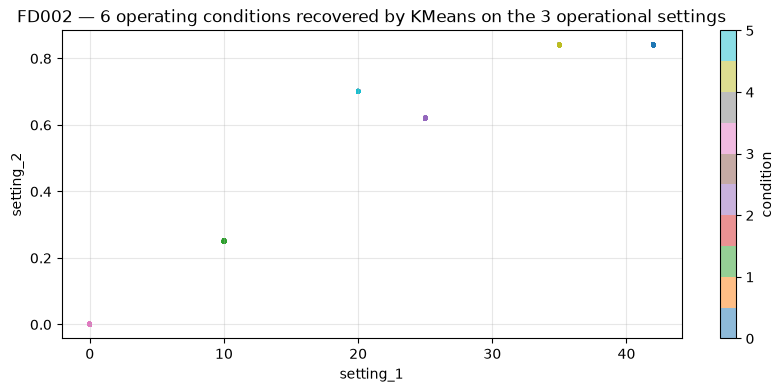

In [7]:
fd002 = load_subset("FD002")

train_c, test_c, kmeans = assign_operating_condition(fd002.train, fd002.test, n_conditions=6)

fig, ax = plt.subplots()
scatter = ax.scatter(
    train_c.setting_1, train_c.setting_2, c=train_c.condition, cmap="tab10", s=4, alpha=0.5
)
ax.set_xlabel("setting_1")
ax.set_ylabel("setting_2")
ax.set_title("FD002 — 6 operating conditions recovered by KMeans on the 3 operational settings")
plt.colorbar(scatter, label="condition")
plt.show()


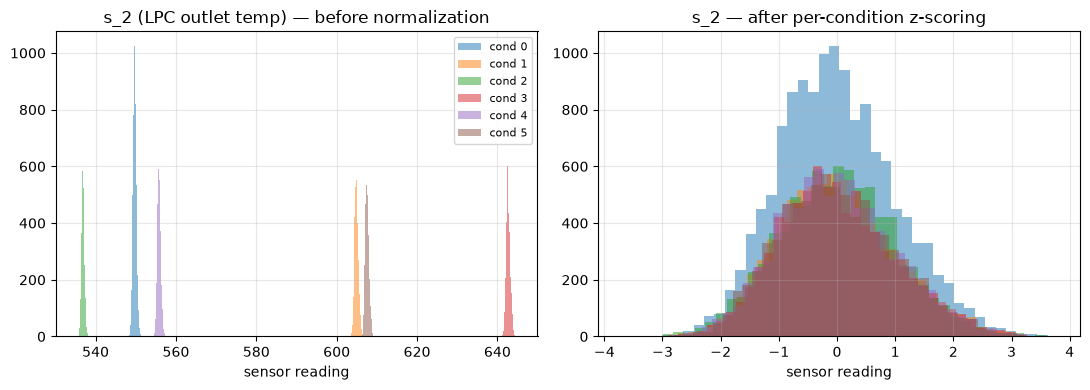

In [8]:
base_cols = select_feature_columns("FD002")
before = train_c.copy()
train_n, test_n, scalers = normalize_by_condition(train_c, test_c, base_cols)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for condition in sorted(before.condition.unique()):
    axes[0].hist(before.loc[before.condition == condition, "s_2"], bins=40, alpha=0.5, label=f"cond {condition}")
    axes[1].hist(train_n.loc[train_n.condition == condition, "s_2"], bins=40, alpha=0.5, label=f"cond {condition}")
axes[0].set_title("s_2 (LPC outlet temp) — before normalization")
axes[1].set_title("s_2 — after per-condition z-scoring")
for ax in axes:
    ax.set_xlabel("sensor reading")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()


Before normalization, the six conditions read as six almost-disjoint clusters — a model
would confuse "which regime is this engine in" with "how degraded is it." After per-condition
z-scoring, all six collapse onto a shared, comparable scale, and what's left really is
degradation signal.


## 4. Rolling-window features — smoothing sensor noise

CMAPSS sensor readings are deliberately noisy (NASA's simulator adds measurement noise on
top of the true degradation trend). A single reading is a poor summary of engine state; a
rolling mean over the last several cycles is much more stable, and a rolling standard
deviation captures how *volatile* the signal has become — degrading components often get
noisier, not just worse on average.


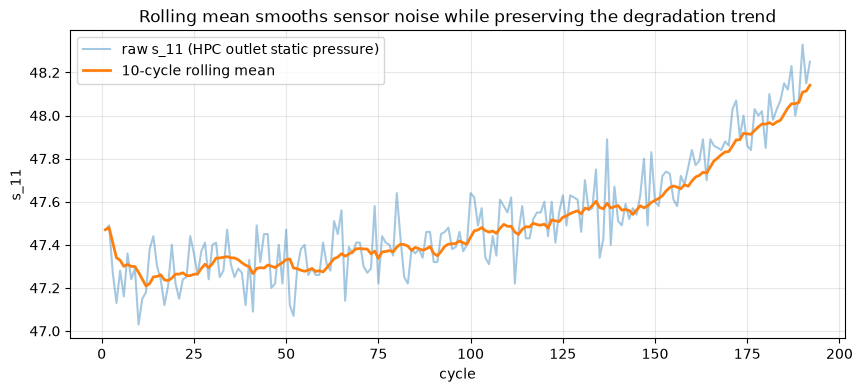

In [9]:
engine1 = fd001.train[fd001.train.unit_number == 1].sort_values("time_cycles")
rolled, roll_cols = add_rolling_features(engine1, ["s_11"], windows=(10,))

fig, ax = plt.subplots()
ax.plot(rolled.time_cycles, rolled.s_11, alpha=0.4, label="raw s_11 (HPC outlet static pressure)")
ax.plot(rolled.time_cycles, rolled.s_11_roll_mean_10, lw=2, label="10-cycle rolling mean")
ax.set_xlabel("cycle")
ax.set_ylabel("s_11")
ax.set_title("Rolling mean smooths sensor noise while preserving the degradation trend")
ax.legend()
plt.show()


## 5. Health Indicator — one interpretable number

Real prognostics systems often fuse dozens of correlated sensors into a single scalar
"health score" that a technician can read at a glance. Ours averages the normalized,
sign-aligned sensors (flipping sign for the sensors that *decrease* with degradation, so
higher always means "worse") and rescales to `[0, 1]`, inverted so **1.0 = healthy** and
**0.0 = failed**.


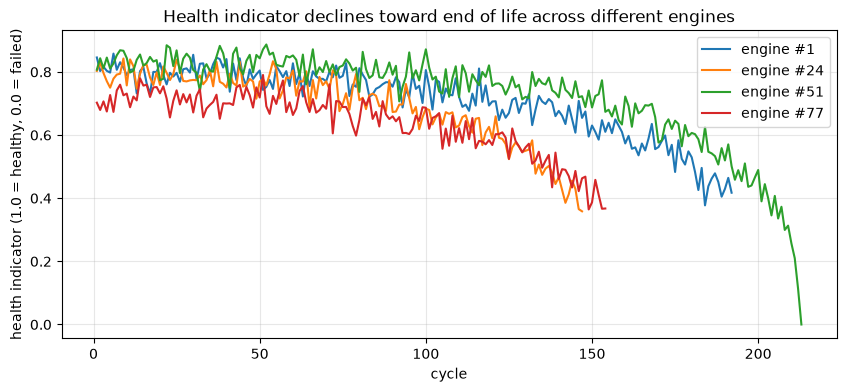

In [10]:
base_cols_fd001 = select_feature_columns("FD001")
labeled_train = add_rul_train(fd001.train, rul_cap=125)
train_cond, test_cond, _ = assign_operating_condition(labeled_train, fd001.test, n_conditions=1)
train_norm, _, _ = normalize_by_condition(train_cond, test_cond, base_cols_fd001)

# sensors that decrease with degradation (flip sign so higher score = more degraded)
degrading_sign = {"s_2": 1, "s_3": 1, "s_4": 1, "s_7": -1, "s_11": -1, "s_12": -1, "s_15": 1, "s_20": -1, "s_21": -1}
train_norm["health_indicator"] = compute_health_indicator(train_norm, base_cols_fd001, degrading_sign)

fig, ax = plt.subplots()
for unit in [1, 24, 51, 77]:
    eng = train_norm[train_norm.unit_number == unit].sort_values("time_cycles")
    ax.plot(eng.time_cycles, eng.health_indicator, label=f"engine #{unit}")
ax.set_xlabel("cycle")
ax.set_ylabel("health indicator (1.0 = healthy, 0.0 = failed)")
ax.set_title("Health indicator declines toward end of life across different engines")
ax.legend()
plt.show()


Every engine's health indicator trends toward 0 as it approaches failure, even though
they fail at wildly different ages (manufacturing variation + different initial wear, per
the CMAPSS simulation design) — which is exactly the behavior we want from a fused
degradation score.


## 6. Assembling the full pipeline

`aerorul.features.pipeline.build_training_data` runs every step above — RUL labeling,
condition clustering, per-condition normalization, rolling features — for a subset in one
call, and returns a `FittedPipeline` that can replay the exact same transformation on new,
unlabeled data (this is what the API uses at inference time).


In [11]:
train_df, test_df, pipeline, data = build_training_data("FD001")

print("Base features (settings + sensors):", len(pipeline.base_feature_cols))
print("All features (base + rolling stats):", len(pipeline.all_feature_cols))
print("Train rows:", train_df.shape, " Test rows:", test_df.shape)
train_df[pipeline.all_feature_cols].describe().T.head(8)


Base features (settings + sensors): 17
All features (base + rolling stats): 119
Train rows: (20631, 130)  Test rows: (13096, 130)


,count,mean,std,min,25%,50%,75%,max
setting_1,20631.0,1.377622e-18,1.000024,-3.973523,-0.681734,0.004055,0.689845,3.981634
setting_2,20631.0,-3.134089e-17,1.000024,-2.055419,-0.690488,-0.008022,1.015677,2.039375
setting_3,20631.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
s_2,20631.0,6.410348e-14,1.000024,-2.941625,-0.711809,-0.081860,0.638080,3.697829
s_3,20631.0,-1.249503e-14,1.000024,-3.177804,-0.695338,-0.069013,0.629079,4.303846
s_4,20631.0,9.147407e-16,1.000024,-2.964737,-0.730389,-0.099305,0.624553,3.617202
s_7,20631.0,-3.159162e-14,1.000024,-3.974497,-0.630132,0.081676,0.725692,3.041891
s_8,20631.0,1.008276e-12,1.000024,-2.770375,-0.657216,-0.093707,0.610680,6.527526


## 7. Caching processed features

`scripts/build_features.py` runs this same pipeline and writes the result to
`data/processed/*.parquet`, so downstream notebooks (and the training scripts) don't have to
recompute KMeans/scaling/rolling features from raw text every time.

```bash
uv run python scripts/build_features.py --subset all
```


## Summary

- Raw CMAPSS data is unlabeled engine-cycle sensor logs — RUL has to be derived, and how you
  derive it (capped vs. uncapped) is a real modeling decision with real evaluation
  consequences (see notebook 03).
- Multi-condition subsets (FD002/FD004) need condition-aware normalization or the model
  spends its capacity distinguishing operating regime instead of degradation.
- Rolling statistics and a fused health indicator both trade raw sensor noise for a cleaner,
  more model-friendly signal — visibly so, as the plots above show.
- Everything here is wrapped in `FittedPipeline`, so the exact same transformation applies
  consistently at training time and at inference time (notebook 05).

**Next:** `02_eda_analysis.ipynb` digs deeper into what the data actually looks like across
all four subsets before we start modeling.
